## 타이타닉 생존율울 위한 데이터 분석 - EDA기반 데이터 분석
```txt
EDA는 데이터를 시각화하고 요약 통계를 통해 데이터 구조, 이상치발견, 패턴 등을 발견하는 활동이다<br>

EDA주요 목적
  - 데이터 이해
  - 이상치 발견
  - 가설 설정
  - 데이터 변환

EDA의 주요기법
  - 기술통계
  - 데이터 시각화: seaborn설치, 사용
  - 상관분석: 두 변수  간의 상관관계를 분석하여 변수 간의 관계를 파악
  - 히트맵( Hitmap ): 상관관계를 시각적으로 표현함
```

회귀나 분류를 적용하기 바로 직전단계에 필요한 활동<br>
시각화, 독립변수 사이 관계( 상관관계 )

In [79]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm # 한글 폰트 관련
from matplotlib import rc
path = "../malgun.ttf"
font_name = fm.FontProperties(fname=path).get_name()
rc('font', family=font_name)
plt.rc('font', family="Malgun Gothic")

In [80]:
import warnings
warnings.filterwarnings(action='ignore')

In [81]:
df_train = pd.read_csv('../data/titanic/train.csv') # 학습( 훈련데이터 ) - 공부
# df_test = pd.read_csv('../data/titanic/test.csv') # 시험
# submission = pd.read_csv('../data/titanic/gender_submission.csv')

STEP#3-1. Target변수( Servived ) 

In [82]:
df_train['Survived'].value_counts

<bound method IndexOpsMixin.value_counts of 0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64>

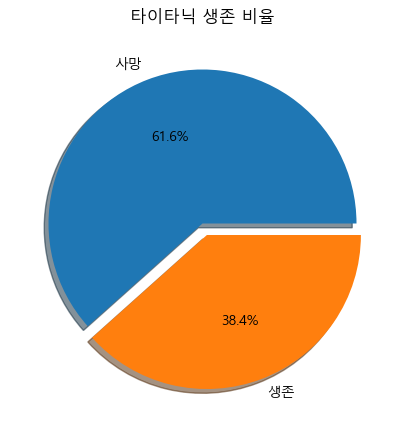

In [83]:
plt.figure(figsize=(8, 5))
labels = ['사망', '생존']
df_train["Survived"].value_counts().plot.pie(explode=[0,0.08]
  , autopct = '%1.1f%%'
  , shadow=True, labels=labels
)
plt.title('타이타닉 생존 비율')
plt.show()

```txt
클래스 분포 확인
클래스 불균형 확인
생존/사망 비율 직관적으로 파악
분류 문제 에서는 클래스 불균형 여부를 확인하는 단계에 해당
사망: 62%
생존: 38%
뷸균형이 심하지 않아 일반 분류 모델 사용 가능해 보임
비율이 극단적이면 모델 전략을 바꿔야 함.

정리
타겟 변수 분포 확인
클래스 불균형 및 모델 전략 결정
평가 지표 선택 을 위함 근거 마련 하기 과정임
```

STEP#3-2. 성별( 남성: male, 여성: female )

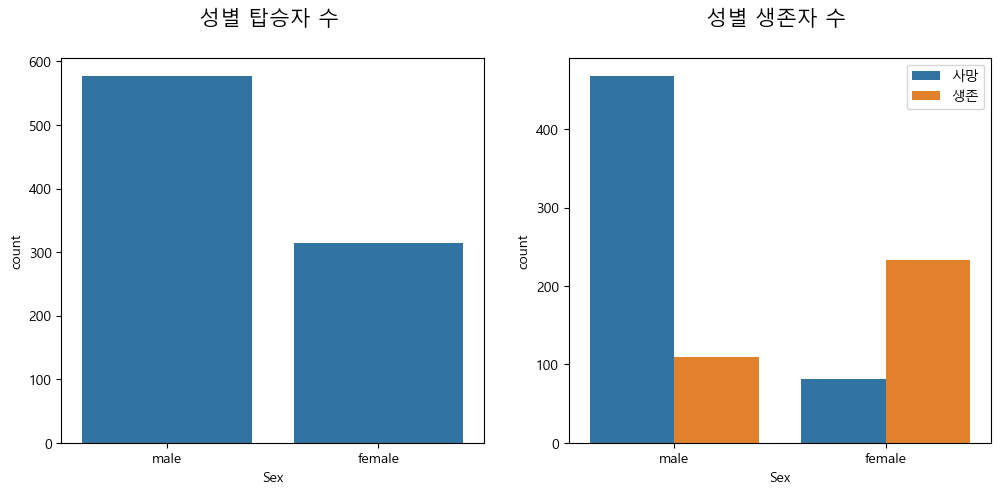

In [84]:
# 1행 2열짜리 그래프 공간 할당
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].set_title("성별 탑승자 수 \n", size=15)
sns.countplot(x="Sex", data=df_train, ax=axes[0])
axes[1].set_title("성별 생존자 수 \n", size=15)

# countplot 범주형 변수의 빈도( 개수 ) 막대로 보여줌
sns.countplot(x="Sex", hue="Survived", data=df_train, ax=axes[1])
axes[1].legend(labels = ['사망', '생존'])

```txt
표본이 성별로 얼마나 불균형 한지 확인
이후에 생존분석에서 "여성이 많이 살아남았다" 를 해석할 때 판단 근거가 됨.
성별이 생존에 영향이 있는지 여부 확인
분류 문제에서 유의미한 feature후보인지 판단
```

STEP#3-3. 티켓 클래스( Pclass )<br>
티켓 클래스 별로 어떤 생존율을 보이고 있는가?
- 1등석: 63%
- 2등석: 47%
- 3등석: 24%

In [85]:
# df.groupby('기준년월')
df_train[["Pclass", "Survived"]].groupby('Pclass').mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


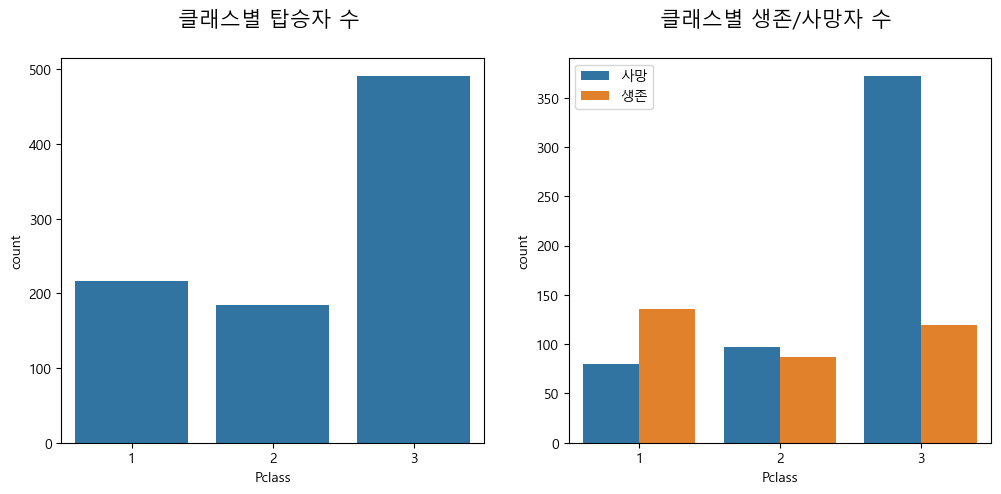

In [86]:
# 시각화 실습 - 1,2했을 때 두 개의 차트
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].set_title("클래스별 탑승자 수 \n", size=15)

sns.countplot(x="Pclass", data=df_train, ax=axes[0])
axes[1].set_title("클래스별 생존/사망자 수 \n", size=15)
sns.countplot(x="Pclass", hue="Survived", data=df_train, ax=axes[1])
axes[1].legend(labels = ['사망', '생존'])

```txt
정리
객식 등급이 높을 수록 생존 확률이 높다면 모델은 학습학 된다.
등급이 낮을 수록 생존율 감소를 보이고 있어 선형 모델 가능할 것으로 보임
트리 모델도 가능해 보임
feature에 대한 중요도가 높음 -> 상관관계 강함
모델 feature선택 근거 마련에 도움.
```

STEP#3-4. 나이( Age )<br>
결측치가 존재함. -> 결측치 처리하는 방법은?<br>
탑승객들의 평균 나이는 30세.<br>
탑승객들의 나이는 주로 20~40세에 분포하고 있음<br>

In [87]:
df_train['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: xlabel='Age', ylabel='Density'>

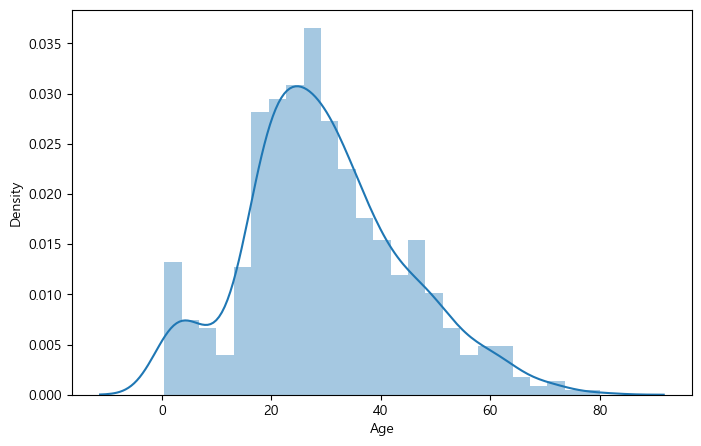

In [88]:
plt.figure(figsize=(8, 5))
# sns.histplot(df_train['Age'], bins=25)
sns.distplot(df_train['Age'], bins=25)

```txt
분포 형태 확인( 정류분포 형태인지, 한쪽으로 치우쳐 있는지 )
평균값과 중앙값 차이 관찰
전처리 전략 결정
- Age가 결측치가 많음
- 평균으로 할지, 중앙값 대체, 그롭별 대체, ,,
```

STEP#3-5. 함께 탑승한 가족의 수( SipSp, Parch )
- SipSp: 함께 탑승한 형제자매, 배우자 수 총합
- Parch: 함께 탑승한 부모, 자녀 수 총합
- 둘 다 가족의 수 이므로 비슷한 경향을 가질 것으로 판단됨.

In [89]:
df_train[["SibSp", "Survived"]].groupby('SibSp').mean()

,Survived
SibSp,
0,0.345395
1,0.535885
2,0.464286
3,0.250000
4,0.166667
5,0.000000
8,0.000000


In [90]:
df_train[["Parch", "Survived"]].groupby('Parch').mean()

,Survived
Parch,
0,0.343658
1,0.550847
2,0.500000
3,0.600000
4,0.000000
5,0.200000
6,0.000000


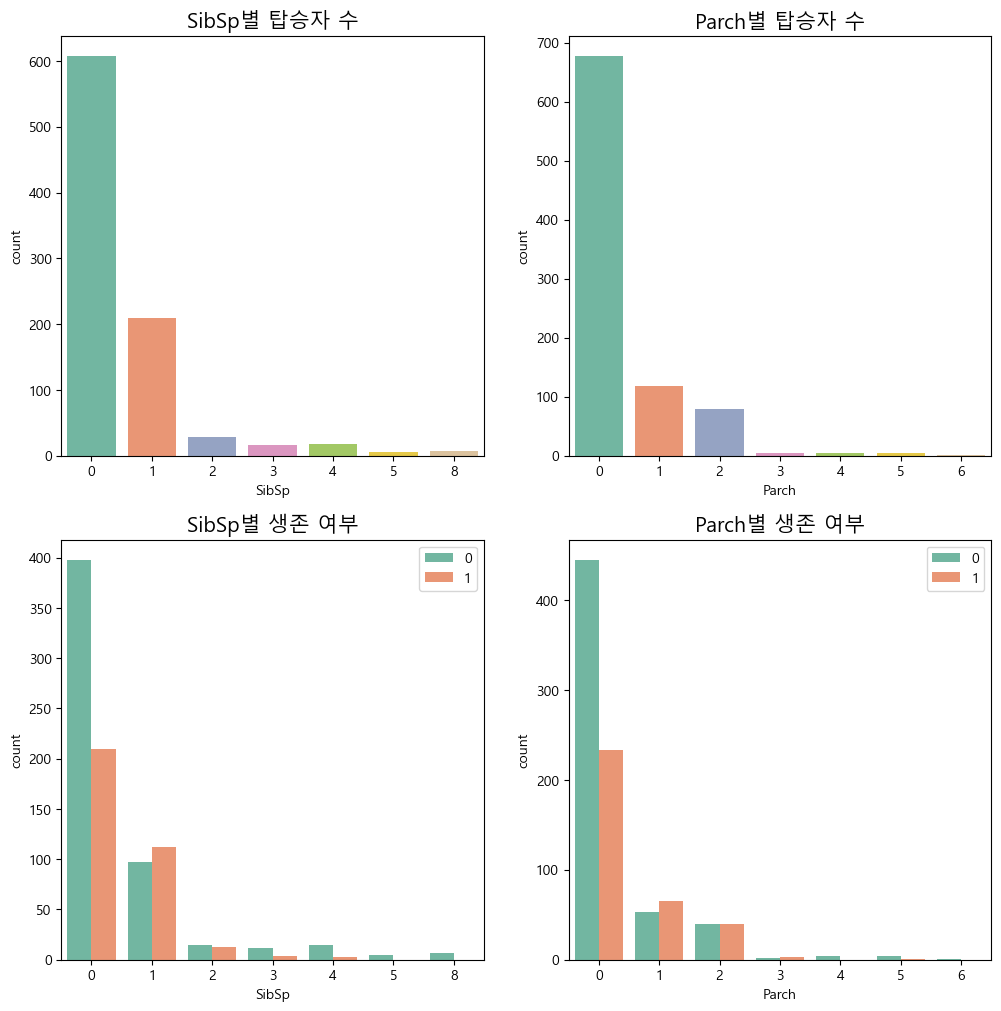

In [91]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0][0].set_title("SibSp별 탑승자 수", size=15)
sns.countplot(x="SibSp", data=df_train, ax=axes[0][0], palette="Set2")
axes[0][1].set_title("Parch별 탑승자 수", size=15)
sns.countplot(x="Parch", data=df_train, ax=axes[0][1], palette="Set2")

axes[1][0].set_title("SibSp별 생존 여부", size=15)
sns.countplot(x="SibSp", hue="Survived", data=df_train, ax=axes[1][0], palette="Set2")
axes[1][0].legend(loc='upper right')
axes[1][1].set_title("Parch별 생존 여부", size=15)
sns.countplot(x="Parch", hue="Survived", data=df_train, ax=axes[1][1], palette="Set2")
axes[1][1].legend(loc='upper right')

```txt
정리
가족 동반 수에 따라 생존 패턴이 달라지는가?
혼자 탑승: 사망 비율이 상대적으로 높은 편이다.
1~2명 동반: 완전 혼자보다는 유지하지 않을까?
4인 이상 동반: 표본수가 적음. 집단 이동 어려움
가족 규모가 중요한 Feature 후보인지 판단해 보자.
```

STEP#3-6. 탑승항구( Embarked )

In [92]:
df_train[['Embarked', 'Survived']]

,Embarked,Survived
0,S,0
1,C,1
2,S,1
3,S,1
4,S,0
...,...,...
886,S,0
887,S,1
888,S,0
889,C,1


In [93]:
df_train[['Embarked', 'Survived']].groupby(['Embarked']).mean()

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


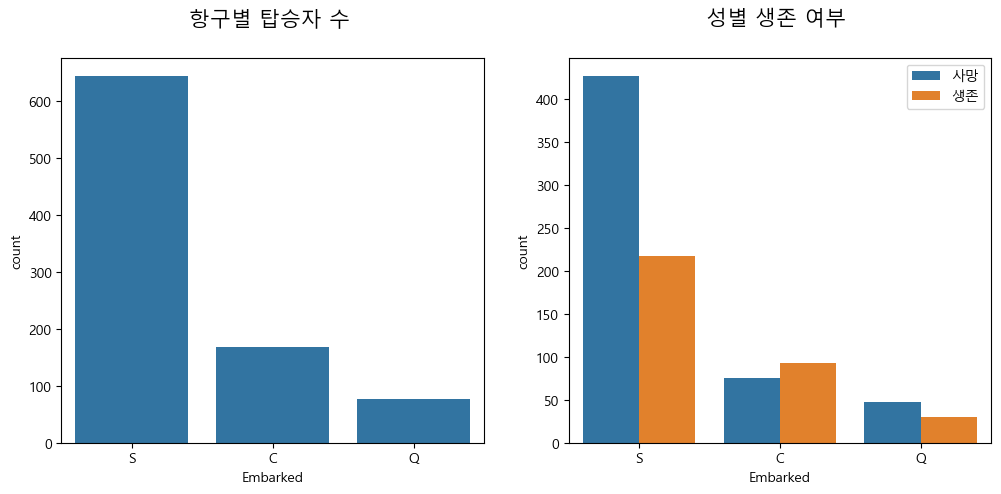

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("항구별 탑승자 수 \n", size=15)
sns.countplot(x="Embarked", data=df_train, ax=axes[0])

axes[1].set_title("성별 생존 여부 \n", size=15)
sns.countplot(x="Embarked", hue="Survived", data=df_train, ax=axes[1])
axes[1].legend(labels = ['사망', '생존'])

```txt
어느 항구에서 많이 탑승했는지 확인
데이터 불균형 여부
Cherboug탑승자는 1등석 비율이 높았을까?
Southampton은 3등석 승객이 많은 것 아닌가?
사회경제적 요인 고려...

어느 항구에서 출발한 사람들이 더 많이 살아남았는가?
아니면
항구 자체가 아니라 그 항구에서 탑승한 사람들의 계층/객실 등급일 가능성이 더 높지 않은지?
```

STEP#3-7. 객실등급별 승선 항구 분포 비교

<Axes: >

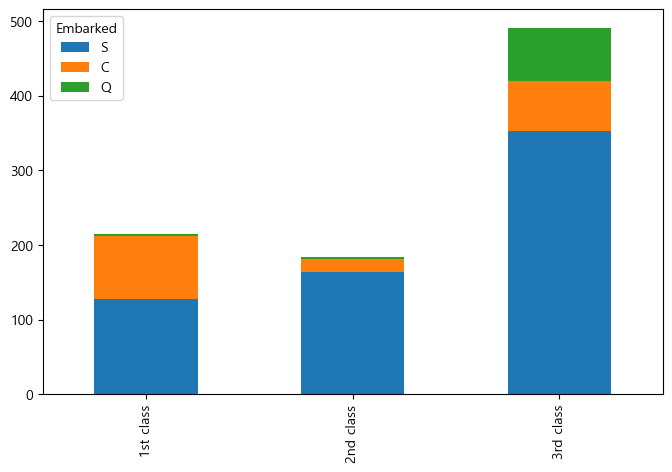

In [ ]:
# 객실 등급별로 승선 항구 분포를 비교하기
# 어느 등급 승객이 어느 항구에서 많이 탑승했는가?
pc1 =  df_train[df_train["Pclass"] == 1]["Embarked"].value_counts()
pc2 =  df_train[df_train["Pclass"] == 2]["Embarked"].value_counts()
pc3 =  df_train[df_train["Pclass"] == 3]["Embarked"].value_counts()
pc = pd.DataFrame([pc1, pc2, pc3])
pc.index = ["1st class", "2nd class", "3rd class"]
fig,  ax = plt.subplots(figsize=(8,5))
pc.plot(kind="bar", stacked=True, ax =ax)

In [98]:
pc = pd.DataFrame([pc1, pc2, pc3])
pc.index = ['1st class', '2nd class', '3st class']
pc

Embarked,S,C,Q
1st class,127,85,2
2nd class,164,17,3
3st class,353,66,72


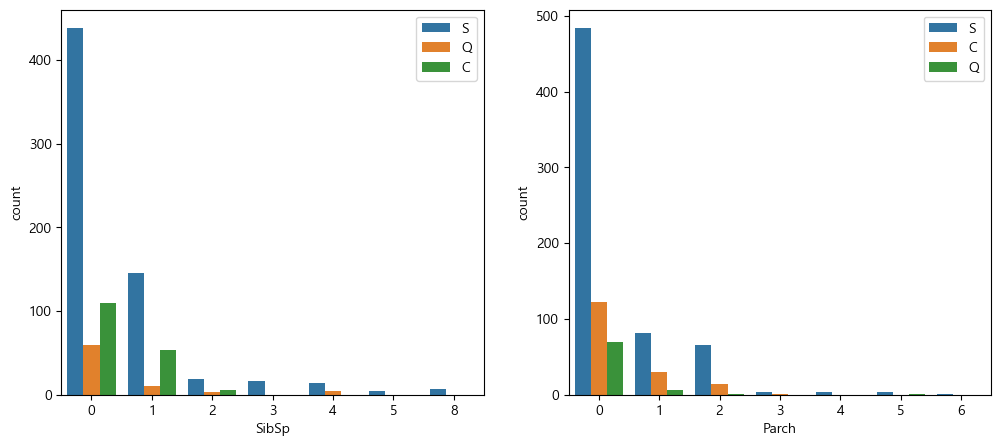

In [96]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df_train, x='SibSp', hue='Embarked', ax=ax[0])
sns.countplot(data=df_train, x='Parch', hue='Embarked', ax=ax[1])
ax[0].legend(loc='upper right')
ax[1].legend(loc='upper right')
plt.show()

STEP#3-8. 탑승금액( Fare )<br><br>
요금이 높을수록 생존 확율이 높았는가? 시각적으로 확인하기<br><br>
비싼 좌석 -> 상층 -> 구조 유리<br>
싼 좌성 -> 하층 -> 침수 위험<br>
요금 = 객실 등급과 강한 연관<br>

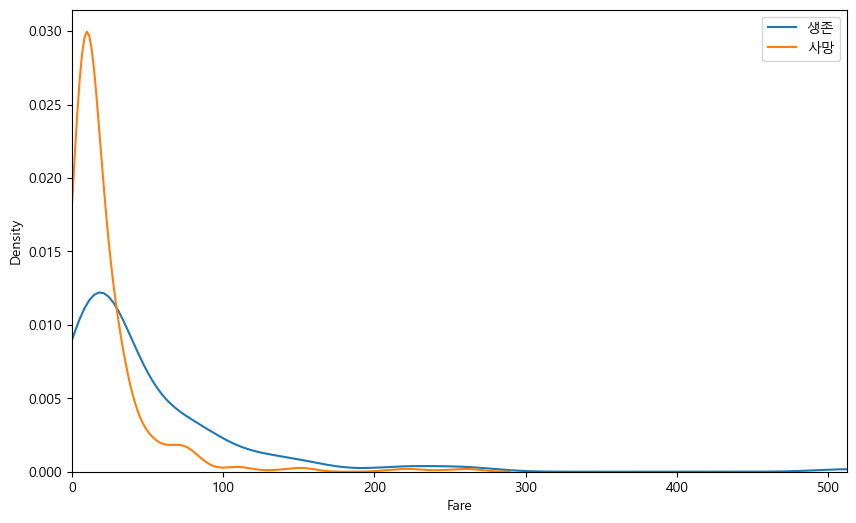

In [ ]:
# 요금 분포를 생존 여부에 따라 비교하는 그래프
fig, ax = plt.subplots(figsize=(10,6))

# 분포 확인
sns.kdeplot(df_train[df_train['Survived']==1]['Fare'], ax=ax)
sns.kdeplot(df_train[df_train['Survived']==0]['Fare'], ax=ax)

# 축 범위
ax.set(xlim=(0, df_train['Fare'].max()))
ax.legend(['생존', '사망'])

plt.show()

```txt
이 프로젝트에서 마지막 페이지에 들어갈 내용

모델링: 여러 가지 알고리즘을 돌려보고 점수가 좋은 것을 최좀 모델로 선정하자.
  모델링이 예측한 값과 설제 값이 얼마나 일치하는 지를 나타내는 지표: accuracy_score 

훈련데이터의 정확도
  모델이 훈련 데이터에 대해 얼마나 일관 되게 학습했는지 평가

모델 성능이 차이나는 이유
모델 튜닝
  성능 평가: 정밀도, 재현율, F1점수 등 다양한 지표 소개

모델 손실율 계산
```